# Check uncertainty consistency between IFY's and CFY's

In [1]:
import sandy

In [2]:
import numpy as np
import pandas as pd
import scipy
from scipy.stats import bootstrap

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

## Get decay data from JEFF-3.3

In [4]:
tape_rdd = sandy.get_endf6_file("jeff_33", "decay", "all")

rdd = sandy.DecayData.from_endf6(tape_rdd)

In [5]:
tape = sandy.get_endf6_file("jeff_33", "nfpy", [922350, 922380, 942390, 942410])

In [6]:
file = "fy.jeff33"
text = tape.write_string()
with open(file, mode="w") as f:
    f.write(text)

## Get fission yields from JEFF-3.3 and from CEA evaluation

In [7]:
fy = sandy.Fy.from_endf6(tape)

In [8]:
fy_u235t = sandy.Fy.from_endf6(sandy.Endf6.from_file(sandy.fy_cea_u235th))
fy_pu239t = sandy.Fy.from_endf6(sandy.Endf6.from_file(sandy.fy_cea_pu239th))

## Get samples

This tests the entire sampling process.

In [9]:
nsmp = 50
sandy.sampling.run(f"{file} --samples {nsmp} --fycov".split())

 - Parsing input file options...
	fy.jeff33 --samples 50 --fycov


 - Processing file: 'fy.jeff33'...


########################################################


                GET PERTURBATIONS                       


########################################################


    2/597871 covariance coefficients are set to -1+eps.
    The smallest covariance is -1.05256
    


########################################################


              APPLY PERTURBATIONS                       


########################################################


Total running time: 65.30 sec


In [10]:
outs = {k: sandy.Fy.from_endf6(sandy.Endf6.from_file(f"fy_{k}")) for k in range(nsmp)}

## Test 1: CEA covariance for U-235 thermal

In [11]:
cfys = pd.concat([v.apply_qmatrix(922350, 0.0253, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [12]:
jeff_cfys = {
    "Nd148": fy.data.query("ZAP==601480 and ZAM==922350 and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy.data.query("ZAP==601440 and ZAM==922350 and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy.data.query("ZAP==601430 and ZAM==922350 and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy.data.query("ZAP==601450 and ZAM==922350 and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy.data.query("ZAP==551370 and ZAM==922350 and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy.data.query("ZAP==551330 and ZAM==922350 and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy.data.query("ZAP==380900 and ZAM==922350 and E==0.0253 and MT==459").squeeze(),
}

In [13]:
ref_cfys = {
    "Nd148": fy_u235t.data.query("ZAP==601480 and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_u235t.data.query("ZAP==601440 and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_u235t.data.query("ZAP==601430 and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_u235t.data.query("ZAP==601450 and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_u235t.data.query("ZAP==551370 and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_u235t.data.query("ZAP==551330 and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_u235t.data.query("ZAP==380900 and E==0.0253 and MT==459").squeeze(),
}

In [14]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==922350 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==922350 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==922350 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==922350 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==922350 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==922350 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==922350 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

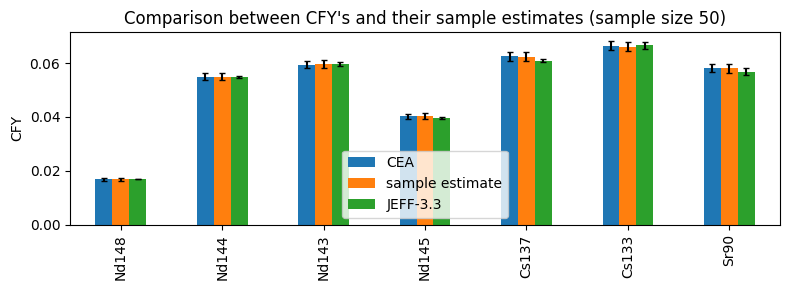

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "CEA": {k: v.FY for k, v in ref_cfys.items()},
    "STD": {k: v.DFY for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in jeff_cfys.items()},
    "JEFF_STD": {k: v.DFY for k, v in jeff_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).merge(j, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["CEA", "sample estimate", "JEFF-3.3"], yerr={"CEA": d.STD, "sample estimate": d.SMP_STD, "JEFF-3.3": d.JEFF_STD}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY", xlabel=None, title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

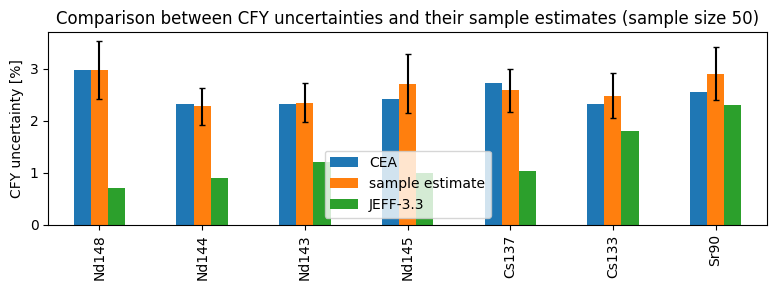

In [16]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "CEA": {k: v.DFY / v.FY * 100 for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in jeff_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).merge(j, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["CEA", "sample estimate", "JEFF-3.3"], yerr={"sample estimate": d.STD * 2}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY uncertainty [%]", xlabel=None, title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

## Test 2: CEA covariance for Pu-239 thermal

In [17]:
cfys = pd.concat([v.apply_qmatrix(942390, 0.0253, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [18]:
jeff_cfys = {
    "Nd148": fy.data.query("ZAP==601480 and ZAM==942390 and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy.data.query("ZAP==601440 and ZAM==942390 and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy.data.query("ZAP==601430 and ZAM==942390 and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy.data.query("ZAP==601450 and ZAM==942390 and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy.data.query("ZAP==551370 and ZAM==942390 and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy.data.query("ZAP==551330 and ZAM==942390 and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy.data.query("ZAP==380900 and ZAM==942390 and E==0.0253 and MT==459").squeeze(),
}

In [19]:
ref_cfys = {
    "Nd148": fy_pu239t.data.query("ZAP==601480 and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_pu239t.data.query("ZAP==601440 and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_pu239t.data.query("ZAP==601430 and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_pu239t.data.query("ZAP==601450 and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_pu239t.data.query("ZAP==551370 and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_pu239t.data.query("ZAP==551330 and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_pu239t.data.query("ZAP==380900 and E==0.0253 and MT==459").squeeze(),
}

In [20]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==942390 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==942390 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==942390 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==942390 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==942390 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==942390 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==942390 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

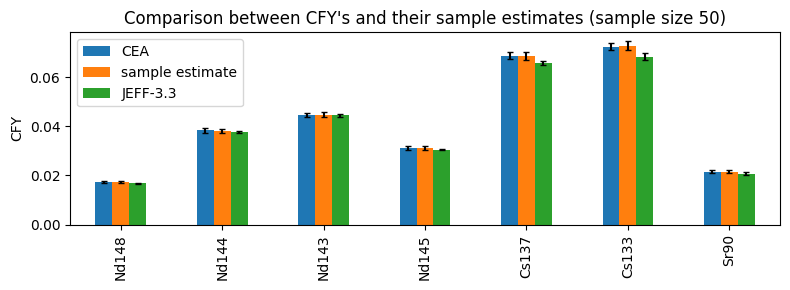

In [21]:
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "CEA": {k: v.FY for k, v in ref_cfys.items()},
    "STD": {k: v.DFY for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in jeff_cfys.items()},
    "JEFF_STD": {k: v.DFY for k, v in jeff_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).merge(j, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["CEA", "sample estimate", "JEFF-3.3"], yerr={"CEA": d.STD, "sample estimate": d.SMP_STD, "JEFF-3.3": d.JEFF_STD}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY", xlabel=None, title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

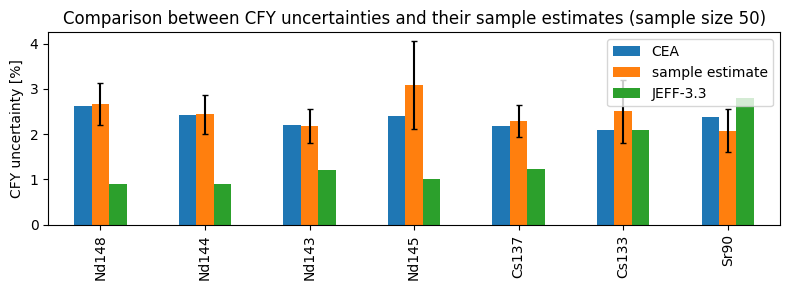

In [22]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "CEA": {k: v.DFY / v.FY * 100 for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in jeff_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).merge(j, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["CEA", "sample estimate", "JEFF-3.3"], yerr={"sample estimate": d.STD * 2}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY uncertainty [%]", xlabel=None, title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

## Test 3: JEFF data for Pu-241 thermal

In [23]:
cfys = pd.concat([v.apply_qmatrix(942410, 0.0253, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [24]:
ref_cfys = {
    "Nd148": fy.data.query("ZAP==601480 and ZAM==942410 and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy.data.query("ZAP==601440 and ZAM==942410 and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy.data.query("ZAP==601430 and ZAM==942410 and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy.data.query("ZAP==601450 and ZAM==942410 and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy.data.query("ZAP==551370 and ZAM==942410 and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy.data.query("ZAP==551330 and ZAM==942410 and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy.data.query("ZAP==380900 and ZAM==942410 and E==0.0253 and MT==459").squeeze(),
}

In [25]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==942410 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==942410 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==942410 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==942410 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==942410 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==942410 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==942410 and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

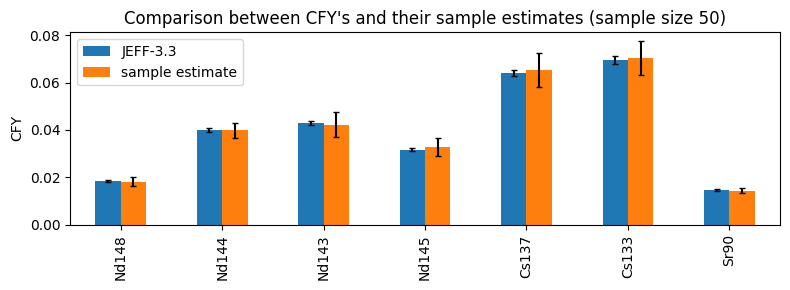

In [26]:
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in ref_cfys.items()},
    "STD": {k: v.DFY for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["JEFF-3.3", "sample estimate"], yerr={"JEFF-3.3": d.STD, "sample estimate": d.SMP_STD}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY", xlabel=None, title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

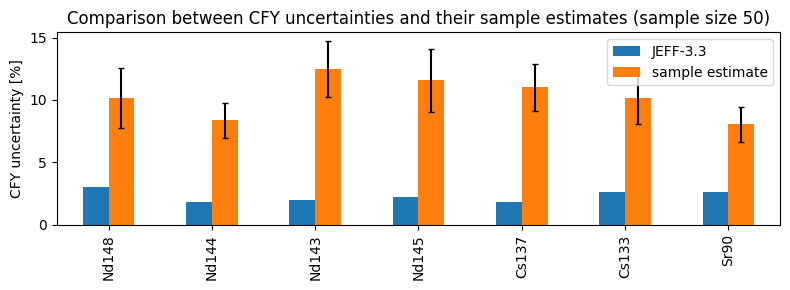

In [27]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["JEFF-3.3", "sample estimate"], yerr={"sample estimate": d.STD * 2}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY uncertainty [%]", xlabel=None, title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

## Test 4: JEFF data for U-238 fast

In [28]:
cfys = pd.concat([v.apply_qmatrix(922380, 4e5, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [29]:
ref_cfys = {
    "Nd148": fy.data.query("ZAP==601480 and ZAM==922380 and E==4e5 and MT==459").squeeze(),
    "Nd144": fy.data.query("ZAP==601440 and ZAM==922380 and E==4e5 and MT==459").squeeze(),
    "Nd143": fy.data.query("ZAP==601430 and ZAM==922380 and E==4e5 and MT==459").squeeze(),
    "Nd145": fy.data.query("ZAP==601450 and ZAM==922380 and E==4e5 and MT==459").squeeze(),
    "Cs137": fy.data.query("ZAP==551370 and ZAM==922380 and E==4e5 and MT==459").squeeze(),
    "Cs133": fy.data.query("ZAP==551330 and ZAM==922380 and E==4e5 and MT==459").squeeze(),
    "Sr90": fy.data.query("ZAP==380900 and ZAM==922380 and E==4e5 and MT==459").squeeze(),
}

In [30]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==922380 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==922380 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==922380 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==922380 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==922380 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==922380 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==922380 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

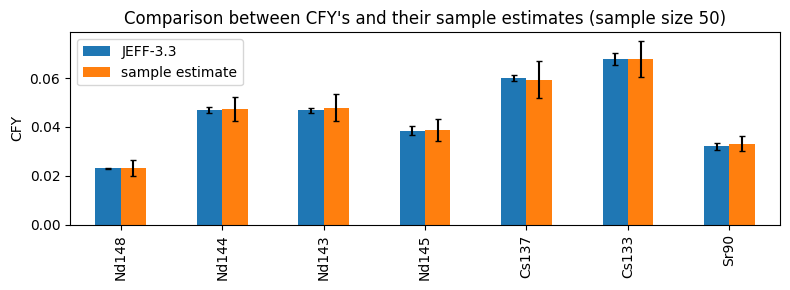

In [31]:
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in ref_cfys.items()},
    "STD": {k: v.DFY for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["JEFF-3.3", "sample estimate"], yerr={"JEFF-3.3": d.STD, "sample estimate": d.SMP_STD}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY", xlabel=None, title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

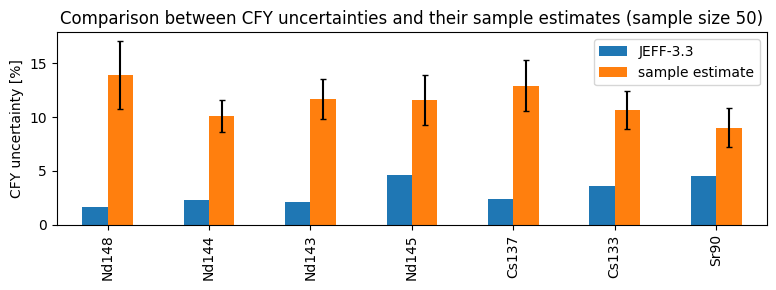

In [32]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["JEFF-3.3", "sample estimate"], yerr={"sample estimate": d.STD * 2}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY uncertainty [%]", xlabel=None, title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

## Test 5: JEFF data for U-235 fast

In [33]:
cfys = pd.concat([v.apply_qmatrix(922350, 4e5, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [34]:
jeff_cfys = {
    "Nd148": fy.data.query("ZAP==601480 and ZAM==922350 and E==4e5 and MT==459").squeeze(),
    "Nd144": fy.data.query("ZAP==601440 and ZAM==922350 and E==4e5 and MT==459").squeeze(),
    "Nd143": fy.data.query("ZAP==601430 and ZAM==922350 and E==4e5 and MT==459").squeeze(),
    "Nd145": fy.data.query("ZAP==601450 and ZAM==922350 and E==4e5 and MT==459").squeeze(),
    "Cs137": fy.data.query("ZAP==551370 and ZAM==922350 and E==4e5 and MT==459").squeeze(),
    "Cs133": fy.data.query("ZAP==551330 and ZAM==922350 and E==4e5 and MT==459").squeeze(),
    "Sr90": fy.data.query("ZAP==380900 and ZAM==922350 and E==4e5 and MT==459").squeeze(),
}

In [35]:
ref_cfys = {
    "Nd148": fy_u235t.data.query("ZAP==601480 and E==4e5 and MT==459").squeeze(),
    "Nd144": fy_u235t.data.query("ZAP==601440 and E==4e5 and MT==459").squeeze(),
    "Nd143": fy_u235t.data.query("ZAP==601430 and E==4e5 and MT==459").squeeze(),
    "Nd145": fy_u235t.data.query("ZAP==601450 and E==4e5 and MT==459").squeeze(),
    "Cs137": fy_u235t.data.query("ZAP==551370 and E==4e5 and MT==459").squeeze(),
    "Cs133": fy_u235t.data.query("ZAP==551330 and E==4e5 and MT==459").squeeze(),
    "Sr90": fy_u235t.data.query("ZAP==380900 and E==4e5 and MT==459").squeeze(),
}

In [36]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==922350 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==922350 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==922350 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==922350 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==922350 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==922350 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==922350 and E==4e5 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

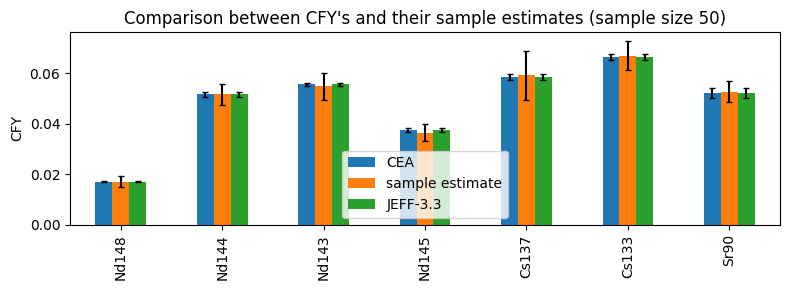

In [37]:
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "CEA": {k: v.FY for k, v in ref_cfys.items()},
    "STD": {k: v.DFY for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in jeff_cfys.items()},
    "JEFF_STD": {k: v.DFY for k, v in jeff_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).merge(j, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["CEA", "sample estimate", "JEFF-3.3"], yerr={"CEA": d.STD, "sample estimate": d.SMP_STD, "JEFF-3.3": d.JEFF_STD}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY", xlabel=None, title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})")

fig.tight_layout()

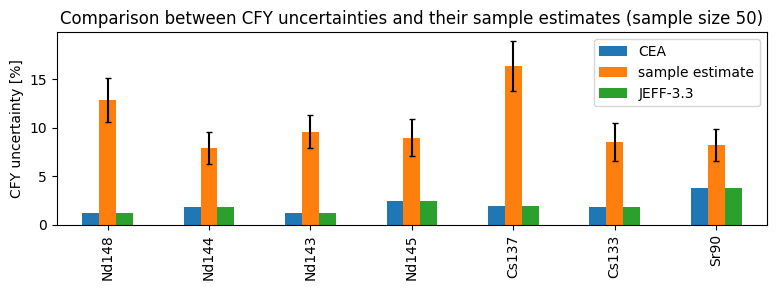

In [38]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

o = pd.DataFrame({
    "CEA": {k: v.DFY / v.FY * 100 for k, v in ref_cfys.items()},
}).rename_axis("NUCL")

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in jeff_cfys.items()},
}).rename_axis("NUCL")

d = o.merge(s, left_index=True, right_index=True).merge(j, left_index=True, right_index=True).reset_index()

d.plot(kind='bar', x="NUCL", y=["CEA", "sample estimate", "JEFF-3.3"], yerr={"sample estimate": d.STD * 2}, capsize=2, ax=ax)
ax.legend()
ax.set(ylabel="CFY uncertainty [%]", xlabel=None, title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})")

fig.tight_layout()